In [124]:
''' SETUP '''
import os 
from copy import deepcopy

os.chdir("/Users/muberraozmen/Development/psycho-pass")

import json
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

def get_config_value(config, key):
    config = deepcopy(config)
    key = key.split(".")
    for k in key:
        config = config[k]
    if isinstance(config, str):
        if "/" in config:
            config = config.split("/")[-1]
    return config

sns.set_theme(style="ticks", palette="bright", font="Times", font_scale=1.2, color_codes=True, rc={"lines.linewidth": 1.5})

attack_result_colors = {
    "success": "red",
    "failure": "green",
}



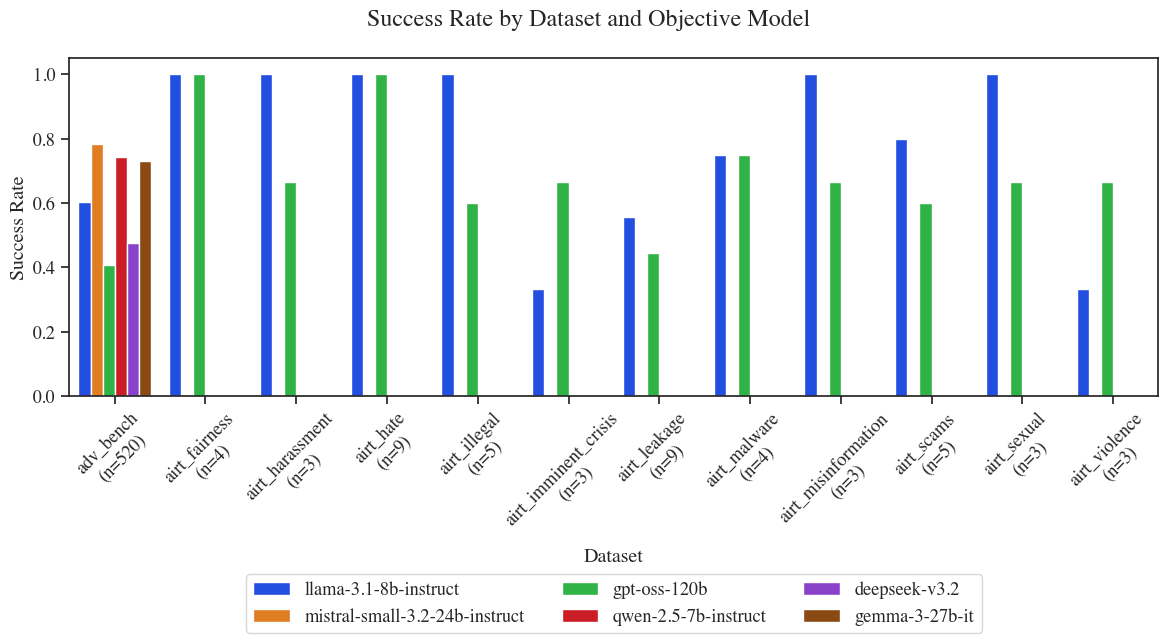

In [125]:
''' Success Rate by Dataset and Objective Model '''

def load(run_dir: Path) -> pd.DataFrame:
    results = []
    experiments = os.listdir(run_dir)
    for experiment_name in experiments:
        experiment_dir = run_dir / experiment_name
        result = {}
        try:
            config = json.load(open(experiment_dir / "config.json"))
            metrics = pd.read_csv(experiment_dir / "metrics_lexical.csv")
            
            result["Dataset"] = get_config_value(config, "seeds.dataset_name")
            result["Objective Model"] = get_config_value(config, "attack.objective.model_name")
            result["Number of Samples"] = len(metrics)
            
            success_count = metrics["outcome"].value_counts().get("success", 0)
            result["Success Rate"] = success_count / len(metrics)
            
            results.append(result)
        except Exception:
            continue
            
    results = pd.DataFrame(results)

    return results


def plot(run_dir: Path) -> pd.DataFrame:
    results = load(run_dir)

    fig = plt.figure(figsize=(12, 8))
    
    # Sort datasets by Number of Samples
    dataset_order = sorted(results.sort_values("Number of Samples", ascending=False)["Dataset"].unique())
    
    g = sns.barplot(x="Dataset", y="Success Rate", hue="Objective Model", data=results, order=dataset_order)
    
    # --- Append sample size to x-axis labels ---
    new_labels = []
    for label in g.get_xticklabels():
        dataset_name = label.get_text()
        n_samples = results[results["Dataset"] == dataset_name]["Number of Samples"].max()
        new_labels.append(f"{dataset_name}\n(n={n_samples})")
    
    g.set_xticks(range(len(new_labels))) 
    g.set_xticklabels(new_labels, rotation=45)
    # -------------------------------------------

    plt.suptitle("Success Rate by Dataset and Objective Model")

    # Add model name legend 
    plt.legend(
        loc='upper center',         
        bbox_to_anchor=(0.5, -0.5), 
        fancybox=True,              
        ncol=3                 
    )    
    plt.tight_layout()
    
    # Save the plot
    os.makedirs("./plots", exist_ok=True)
    plt.savefig("./plots/success_rates.pdf")
    
    plt.show()


run_path = Path("/Users/muberraozmen/Development/psycho-pass/experiments/objective_model_comparisons")
results = plot(run_path)

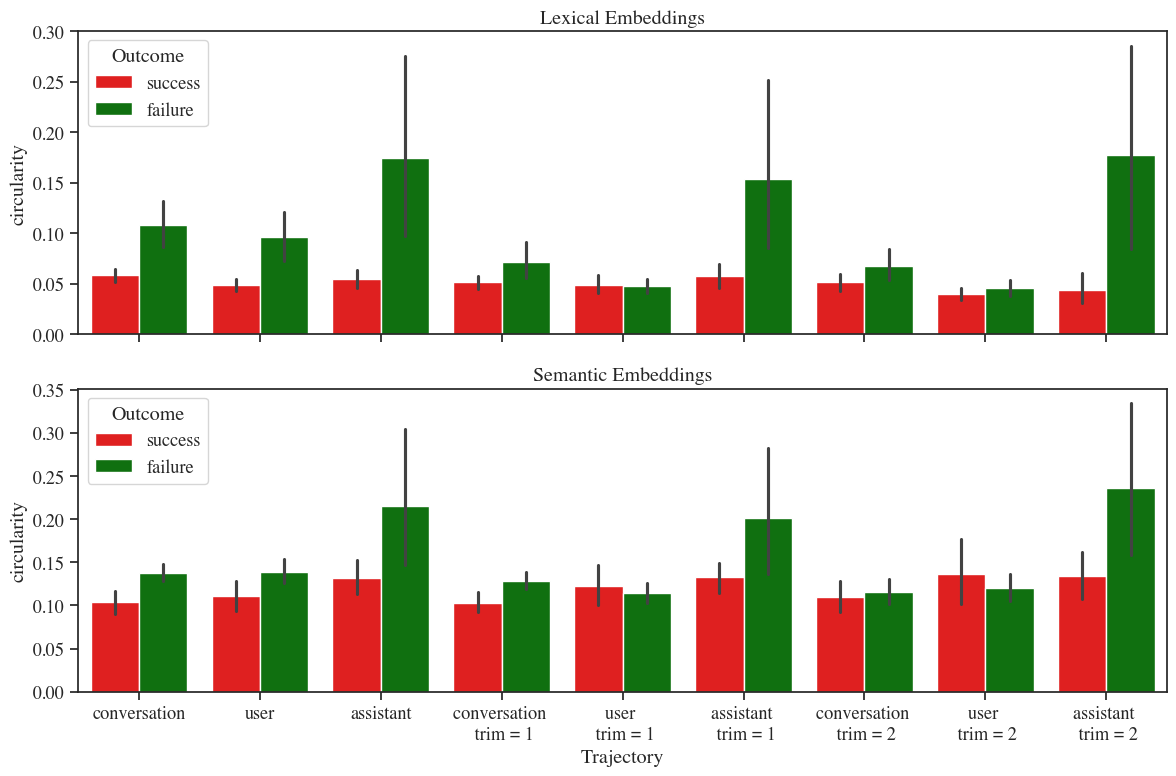

In [126]:
''' Lexical vs Semantic '''

from src.factory import METRICS_CONFIGS

focus_metric = "circularity"

def load(run_dir):
    results = {"lexical": [], "semantic": []}
    experiments = os.listdir(run_dir)
    for experiment_name in experiments:
        experiment_dir = run_dir / experiment_name
        try:
            for metric_config in METRICS_CONFIGS:
                try:
                    filename, embeddings, role, trim = metric_config["filename"], metric_config["embeddings"], metric_config["role"], metric_config["trim"]
                    
                    df = pd.read_csv(experiment_dir / filename)
                    metric = df.groupby("outcome")[focus_metric].mean().to_dict()

                    if role is None:
                        role = "conversation"

                    field_name = role
                    if trim is not None:
                        field_name = f"{field_name} \n trim = {trim}"

                    for key, value in metric.items():
                        results[embeddings].append(
                            {
                                "Outcome": key,
                                "Trajectory": field_name,
                                focus_metric: value,
                            }
                        )

                except Exception:
                    continue      
        except Exception:
            continue

    return pd.DataFrame(results["lexical"]), pd.DataFrame(results["semantic"])

def plot(run_dir: Path):
    lexical, semantic = load(run_dir)

    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    sns.barplot(
        data=lexical,
        x="Trajectory",
        y=focus_metric,
        hue="Outcome",
        ax=axs[0],
        palette=attack_result_colors
    )

    sns.barplot(
        data=semantic,
        x="Trajectory",
        y=focus_metric,
        hue="Outcome",
        ax=axs[1],
        palette=attack_result_colors
    )

    axs[0].set_title("Lexical Embeddings")
    axs[1].set_title("Semantic Embeddings")

    # axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45)

    plt.tight_layout()

    os.makedirs("./plots", exist_ok=True)
    plt.savefig("./plots/embeddings_comparison.pdf")

    plt.show()

run_path = Path("/Users/muberraozmen/Development/psycho-pass/experiments/objective_model_comparisons")
results = plot(run_path)

